<div align="center">
  <h1><b> Quantum Information </b></h1>
  <h2> GHZ State </h2>
</div>

<br>
<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera">Lucas Camponogara Viera</a>

# Table of Contents

- GHZ state
- GHZ-like State


# &nbsp; <img valign="middle" height="45px" src="https://img.icons8.com/python" width="45" hspace="0px" vspace="0px"> Importing modules

In [7]:
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np

# GHZ state

The Greenberger-Horne-Zeilinger (GHZ) state is a maximally entangled state of three qubits defined by:

$$|GHZ \rangle = \frac{1}{\sqrt2}(|000\rangle + |111\rangle).$$

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


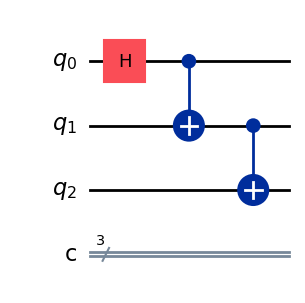

In [8]:
def GHZ():
    qc = QuantumCircuit(3,3) 
    qc.h([0]), qc.cx(0,1), qc.cx(1,2)
    print(Statevector.from_instruction(qc))
    return qc

qc = GHZ()
qc.draw("mpl") 

Measurement results: {'000 000': 498, '111 000': 526}


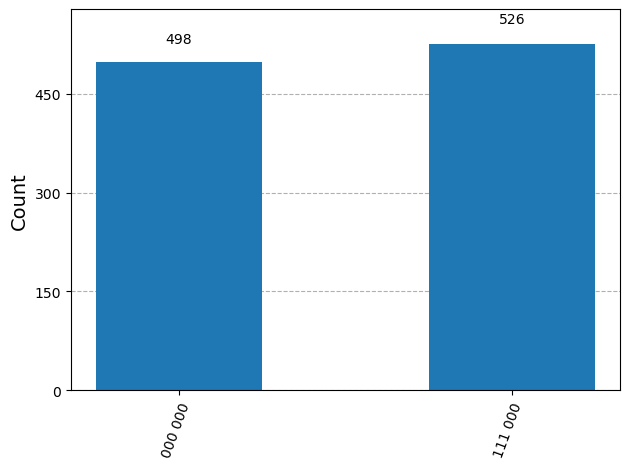

In [9]:
qc.measure_all()                                                  # Measuring all qubits. A quantum computer always measures in the computational basis.
backend = Aer.get_backend('qasm_simulator')                       # Define the Backend for the simulator.
job = backend.run(qc, shots=1024)
result = job.result()
counts = result.get_counts(qc)
print("Measurement results:", counts)                             # 
plot_histogram(counts)                                            # Plot a histogram of outcomes and corresponding probabilities.

# GHZ-like State

A GHZ-like state is the following:

$$|\psi \rangle = \frac{1}{\sqrt2}(|011\rangle - |100\rangle).$$

Statevector([ 0.        +0.j,  0.        +0.j,  0.        +0.j,
              0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
              0.        +0.j,  0.        +0.j],
            dims=(2, 2, 2))


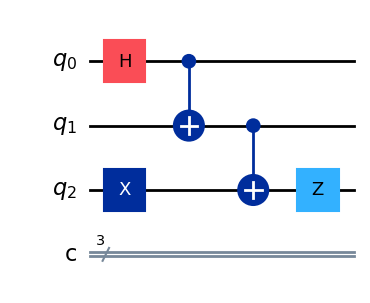

In [10]:
def GHZ_Like():
    qc = QuantumCircuit(3,3) 
    qc.h([0]), qc.x(2), qc.cx(0,1), qc.cx(1,2), qc.z(2)
    print(Statevector.from_instruction(qc))
    return qc

qc = GHZ_Like()
qc.draw("mpl") 

In [11]:
from qiskit.quantum_info import Statevector
import numpy as np

#from qiskit.opflow import One, Zero
#import math

# Define basis states
zero = Statevector.from_label('0')
one = Statevector.from_label('1')

# Build tensor products
state1 = Statevector.from_label('011')  # |011>
state2 = Statevector.from_label('100')  # |100>

# Create GHZ-like superposition
ghz_state = (1/np.sqrt(2)) * (state1.data - state2.data)

# Show as matrix (column vector)
print(ghz_state)

[ 0.        +0.j  0.        +0.j  0.        +0.j  0.70710678+0.j
 -0.70710678+0.j  0.        +0.j  0.        +0.j  0.        +0.j]


Measurement results: {'100 000': 501, '011 000': 523}


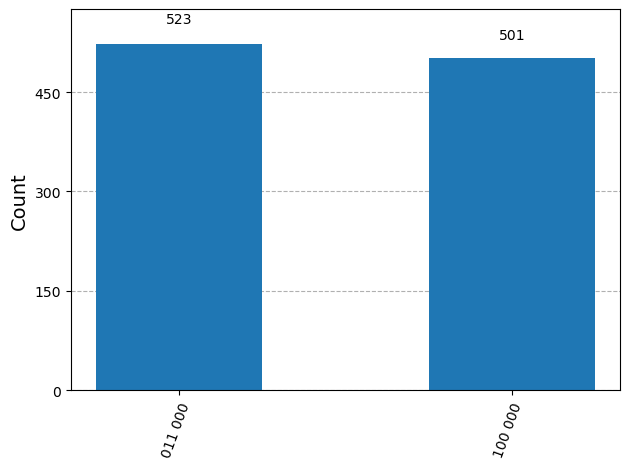

In [12]:
qc.measure_all()                                                  # Measuring all qubits. A quantum computer always measures in the computational basis.
backend = Aer.get_backend('qasm_simulator')                       # Define the Backend for the simulator.
job = backend.run(qc, shots=1024)
result = job.result()
counts = result.get_counts(qc)
print("Measurement results:", counts)                             # 
plot_histogram(counts)                                            # Plot a histogram of outcomes and corresponding probabilities.

# &nbsp; <a href="#"><img valign="middle" height="45px" src="https://img.icons8.com/book" width="45" hspace="0px" vspace="0px"></a> References<a name="ref" />

\[1] Nielsen MA, Chuang IL. 2010. Quantum Computation and Quantum Information. New York: [Cambridge Univ. Press.](https://doi.org/10.1017/CBO9780511976667) 10th Anniv. Ed. 